Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC2017 - Modelación y Simulación - sección 10

Cristian Túnchez (231359)  
Nadissa Vela (23764)  
Javier Linares (231135)  
Ernesto Ascencio (23009)

# **Colapso Hospitalario de Ciudad UVG (pre-intercambio)**

Este cuaderno simula las 72 horas siguientes al sismo de magnitud 6.8 y ayuda a responder tres preguntas:

1. ¿Qué instalación colapsa primero y en qué bloque de 6 horas?
2. ¿Cuál es el recurso cuello de botella?
3. ¿Qué recurso conviene reforzar en ese escenario para reducir las muertes evitables?

Todo el modelo vive en `src/hospital`. Aquí solo se llama y se grafica.

## Las siete reglas del Modelo

El modelo es híbrido. Un motor de **eventos discretos** mueve a los pacientes y un sustrato de **dinámica de sistemas** drena los suministros y la energía del personal.

| Regla | Qué hace |
|---|---|
| **R1** Llegadas | Los heridos llegan a los hospitales según un proceso de Poisson no homogéneo. |
| **R2** Derivación | Cada paciente va a la instalación operativa más cercana con capacidad libre, más un tiempo de traslado. |
| **R3** Requerimiento | Leve: médico. Moderado: médico y cama. Grave: médico, quirófano, UCI y consumibles. |
| **R4** Cola | Prioridad estricta grave > moderado > leve; dentro de cada nivel, el primero que llegó. |
| **R5** Insumos | Cada procedimiento consume una cantidad fija. Si el stock no alcanza, no inicia y el paciente sigue en cola. |
| **R6** Muerte en espera | Cada herido tiene una ventana de supervivencia. Si se agota antes de ser atendido, muere. Este tipo de muerte es clasificada como "evitable". |
| **R7** Fatiga | El personal se cansa con la carga y atiende más lento. |

In [1]:
# El cuaderno solo importa del paquete del modelo
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
from hospital import montecarlo, outputs, params, plots, simulacion

N_REP = 30          # réplicas de Monte Carlo
PROCESOS = None     # None = usar todos los núcleos disponibles
USAR_CACHE = True   # False obliga a recalcular aunque exista el cache

pd.set_option("display.width", 160)

In [2]:
# Datos de partida (R0). Ningún número está escrito en el cuaderno (todo sale de params.py).
p = params.cargar()

instalaciones = pd.DataFrame([{
    "instalación": i.nombre, "zona": i.zona, "camas": i.camas,
    "UCI": i.uci, "quirófanos": i.quirofanos, "operativa": i.operativa,
} for i in p.instalaciones])

heridos = pd.DataFrame([{
    "zona": z.zona, "leves": z.leve, "moderados": z.moderado,
    "graves": z.grave, "total": z.total_atencion,
} for z in p.heridos_t0])

print(instalaciones.to_string(index=False))
print()
print(heridos.to_string(index=False))
print(f"\nHeridos que requieren atención: {heridos['total'].sum()}")
print(f"Médicos que se presentan: {p.medicos_efectivos()} de {p.medicos}")

           instalación zona  camas  UCI  quirófanos  operativa
  Hospital General UVG   Z1    320   24           6       True
            Clínica Z2   Z2     80    4           1       True
       Centro Salud Z3   Z3     45    0           0      False
Hospital Regional Este   Z4    210   18           4       True
       Puesto Salud Z5   Z5     20    0           0       True

zona  leves  moderados  graves  total
  Z1   2840        890     320   4050
  Z2    680        210      58    948
  Z3   1120        380     140   1640
  Z4    410        120      35    565
  Z5   3200        980     390   4570

Heridos que requieren atención: 11773
Médicos que se presentan: 74 de 87


## Paso 1: una réplica

Una réplica es una historia posible de las 72 horas. El simulador mantiene una lista de eventos ordenada por tiempo y va procesando el siguiente: una llegada, el fin de una atención, una muerte en espera, un paso de los suministros.

Al final ningún paciente se pierde; los atendidos, los muertos y los que siguen dentro del sistema suman exactamente los que llegaron.

In [3]:
# Una corrida completa: R1 llegadas, R2 derivación, R3 recursos, R4 cola, R5 insumos, R6 muertes.
una = simulacion.correr(p, seed=params.SEMILLA_BASE)

print(f"Heridos que llegaron:   {una.generados}")
print(f"Atendidos:              {una.atendidos}")
print(f"Muertes evitables:      {una.muertes_evitables}")
print(f"Muertes clínicas:       {una.muertes_clinicas}")
print(f"Todavía en el sistema:  {una.en_sistema}")

suma = una.atendidos + una.muertes_evitables + una.muertes_clinicas + una.en_sistema
print(f"\nSe conservan los pacientes: {suma} == {una.generados}")

Heridos que llegaron:   11340
Atendidos:              8455
Muertes evitables:      2791
Muertes clínicas:       68
Todavía en el sistema:  26

Se conservan los pacientes: 11340 == 11340


## Paso 2: Monte Carlo

Una réplica no basta, pues el resultado depende del azar. Se corren 30 réplicas con semillas independientes y además con los parámetros perturbados, porque los datos de partida son estimaciones y no valores exactos.

Estas 30 réplicas son el **escenario base**: la ciudad con los heridos proyectados, sin la demanda de desplazados del Grupo 1 y sin ninguna intervención. Es el punto de comparación de todo lo que sigue en este cuaderno y, más adelante, será también la referencia contra la que se mida la demanda del Grupo 1 en el cuaderno del intercambio.

De aquí en adelante nunca se reporta un número suelto, sino la media con su intervalo de confianza del 95% (t de Student con n−1 grados de libertad).

In [4]:
# Las 30 réplicas se reparten entre los núcleos disponibles. R1 a R7 se repiten en cada una.
mc = montecarlo.cargar_o_correr(
    "base",
    lambda: montecarlo.correr_replicas(p, n=N_REP, procesos=PROCESOS),
    usar_cache=USAR_CACHE, firma=N_REP,
)

print(f"Réplicas: {mc.n_replicas}")
print(f"patient_log: {mc.patient_log.shape}   state_log: {mc.state_log.shape}"
      f"   stock_log: {mc.stock_log.shape}")
print()
print(mc.patient_log.head(3).to_string(index=False))

Réplicas: 30
patient_log: (339387, 10)   state_log: (138720, 7)   stock_log: (52020, 4)

 replica  pid zona   triage  t_llegada  t_inicio    t_fin          instalacion   estado  espera
       0    0   Z5 moderado   0.000023  0.250023 2.084022      Puesto Salud Z5 atendido    0.25
       0    1   Z3 moderado   0.002219  0.532219 4.806840 Hospital General UVG atendido    0.53
       0    2   Z3     leve   0.002584  0.532584 0.616941 Hospital General UVG atendido    0.53


La media se estabiliza a partir de la réplica 23.


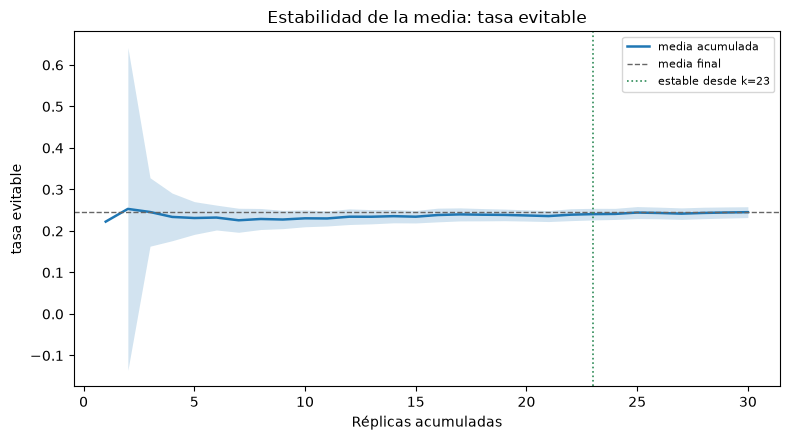

In [5]:
# ¿Alcanzan 30 réplicas? La media acumulada debe aplanarse antes de llegar a la última.
estab = montecarlo.estabilidad_media_acumulada(mc)
plots.estabilidad(estab, metrica="tasa_evitable")

estables = estab.query("metrica == 'tasa_evitable' and estable")
if len(estables):
    print(f"La media se estabiliza a partir de la réplica {int(estables['k'].iloc[0])}.")
else:
    print("La media aún no se estabiliza: conviene subir N_REP.")

## Resultado 1: saturación

Las gráficas muestran el porcentaje de ocupación de cada recurso en los 12 bloques de 6 horas. La línea es la media de las 30 réplicas y la banda es el intervalo de confianza del 95%. La línea punteada marca el 100% (por encima de ella el recurso está agotado).

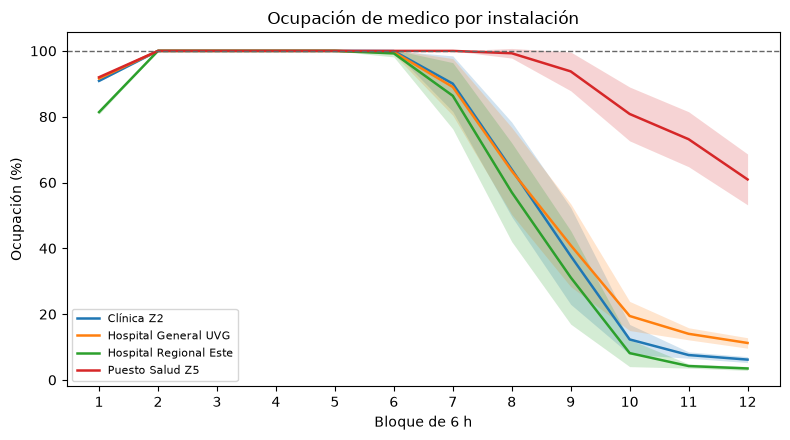

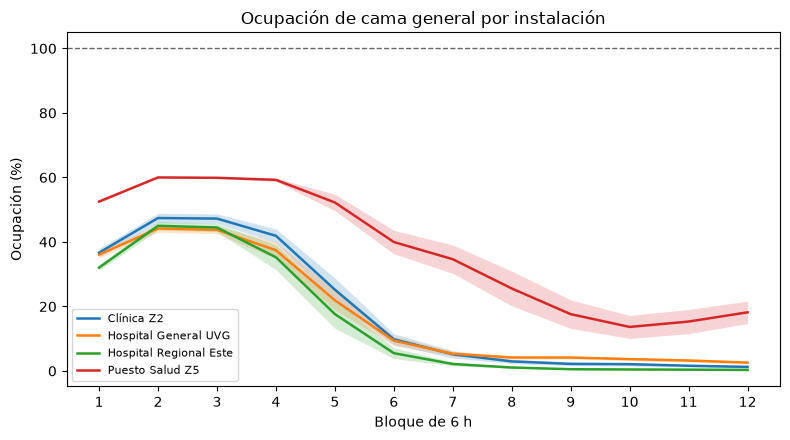

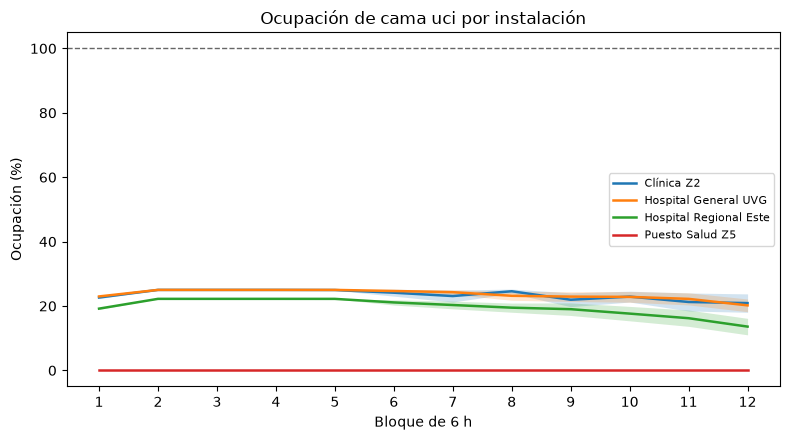

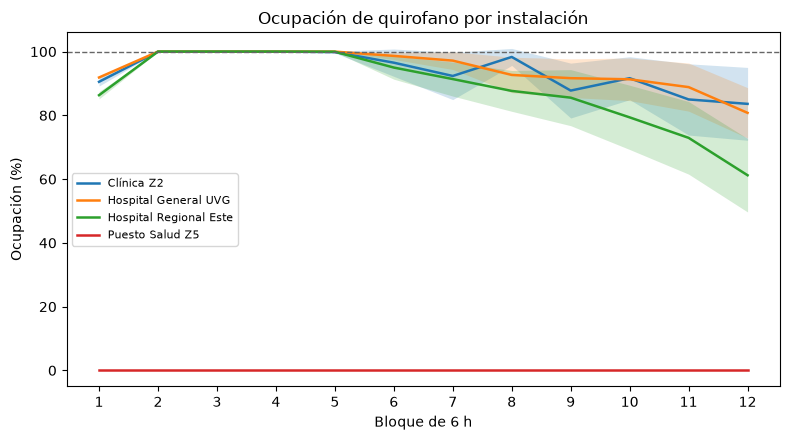

In [6]:
# R2 y R3: dónde termina cada paciente y qué recurso ocupa.
bloques = montecarlo.resumen_bloques(mc)
for recurso in ("medico", "cama_general", "cama_uci", "quirofano"):
    plots.ocupacion_por_bloque(bloques, recurso=recurso)

Cola máxima de graves: 274 pacientes
Cola máxima de moderados: 807 pacientes
Cola máxima de leves: 5894 pacientes


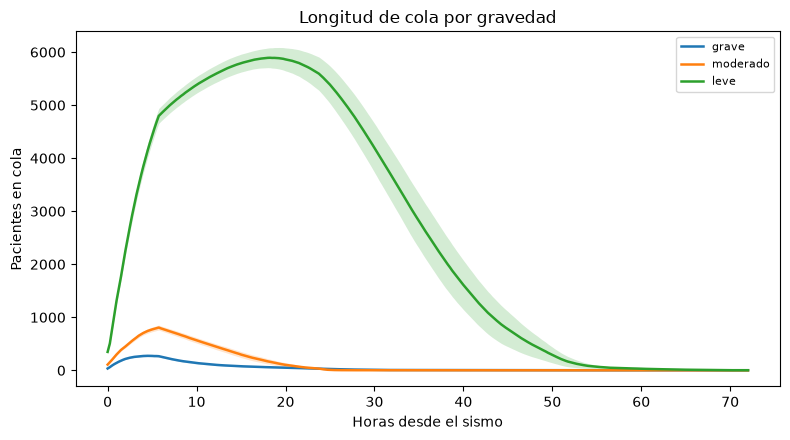

In [7]:
# R4: la cola por gravedad. Los graves tienen prioridad, pero su ventana es la más corta.
cola = montecarlo.cola_por_triage(mc)
plots.cola_por_triage(cola)

picos = cola.groupby("triage")["cola_media"].max()
for triage in ("grave", "moderado", "leve"):
    print(f"Cola máxima de {triage}s: {picos[triage]:.0f} pacientes")

## Resultado 2: insumos y muertes

Los suministros solo bajan. En este escenario no llega reabastecimiento. Cuando uno se agota, el procedimiento que lo necesita no puede iniciar aunque haya cama y médico libres.

Las muertes evitables son las de quienes murieron esperando. Son las que el sistema podría haber prevenido con más capacidad.

Mortalidad evitable: 24.5 % (IC 95 %: 23.2 – 25.8 %)


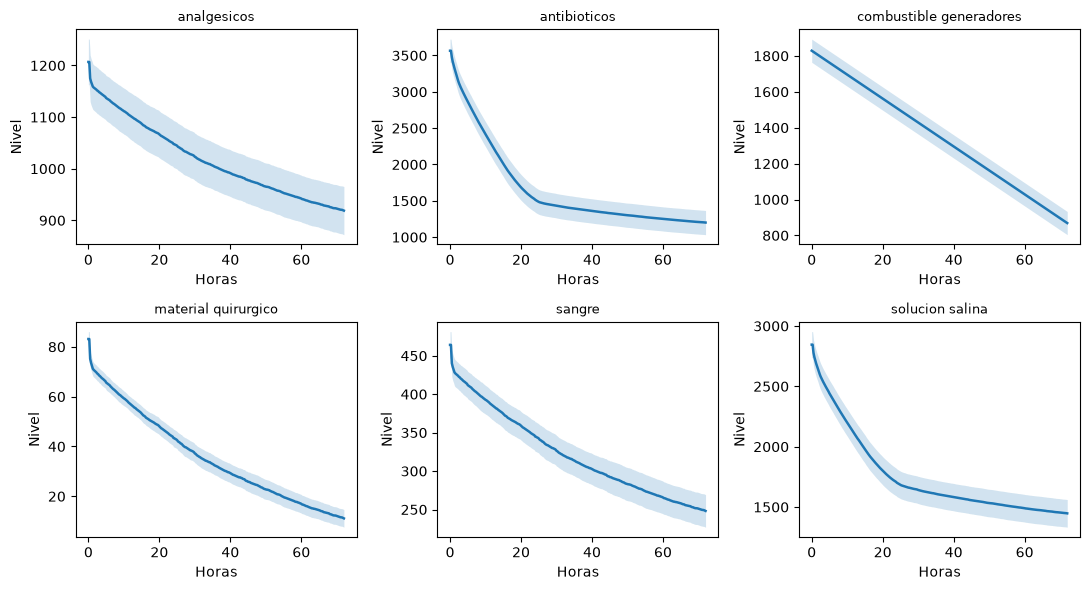

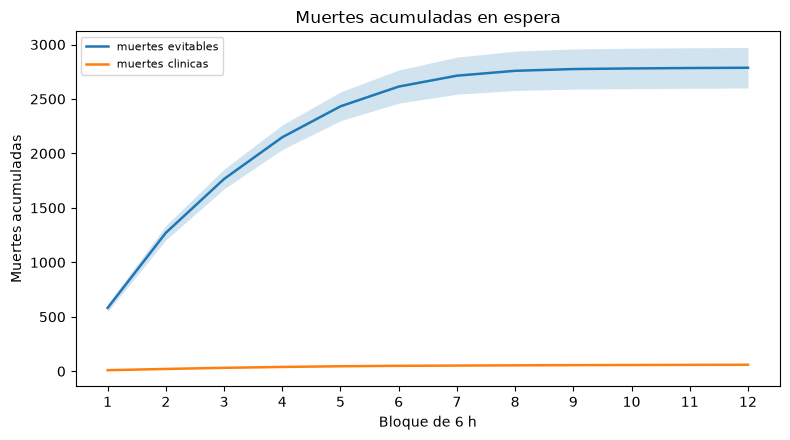

In [8]:
# R5: consumo de cantidad fija por procedimiento, integrado por Euler con Δt = 0.25 h.
plots.stocks_en_tiempo(montecarlo.stocks_en_tiempo(mc))

# R6: muertes acumuladas de quienes agotaron su ventana de supervivencia.
plots.muertes_acumuladas(montecarlo.muertes_por_bloque(mc), tipos=("evitable", "clinica"))

media, bajo, alto = outputs.ic95(mc.tasa_evitable)
print(f"Mortalidad evitable: {100 * media:.1f} % (IC 95 %: {100 * bajo:.1f} – {100 * alto:.1f} %)")

## Resultado 3: qué colapsa primero

Un recurso se considera colapsado en el primer bloque en que queda ocupado casi al 100% y su cola crece de forma sostenida durante al menos dos bloques seguidos.

In [9]:
# Pregunta 1: instalación, bloque y recurso.
colapsos = montecarlo.bloque_de_colapso(mc, df_bloques=bloques)
print(colapsos.to_string(index=False))
print()
print(montecarlo.recurso_cuello_botella(mc).head(5).to_string(index=False))

r = montecarlo.primer_colapso(mc)
print(
    f"\nRESPUESTA: la primera en colapsar es {r['instalacion']} por falta de "
    f"{r['recurso']}, en el bloque {r['bloque']} "
    f"(horas {(r['bloque'] - 1) * 6}–{r['bloque'] * 6}), "
    f"con {100 * r['ocupacion']:.0f} % de ocupación y {r['cola']:.0f} pacientes en cola."
)

           instalacion      recurso  bloque_colapso  ocupacion_media  cola_media  ic95_bajo  ic95_alto
  Hospital General UVG       medico               2         1.000000 2778.411111        1.0        1.0
Hospital Regional Este       medico               2         1.000000 1938.426389        1.0        1.0
            Clínica Z2 cama_general            <NA>         0.474167   92.652778        NaN        NaN
            Clínica Z2     cama_uci            <NA>         0.250000   22.897333        NaN        NaN
            Clínica Z2       medico            <NA>         1.000000  831.651389        NaN        NaN
            Clínica Z2    quirofano            <NA>         1.000000   22.897333        NaN        NaN
  Hospital General UVG cama_general            <NA>         0.441667  270.587500        NaN        NaN
  Hospital General UVG     cama_uci            <NA>         0.250000   82.743056        NaN        NaN
  Hospital General UVG    quirofano            <NA>         1.000000   82

## Resultado 4: sensibilidad

Se relaja cada recurso por separado un 20% y se comparan las muertes evitables contra el escenario base definido. Todos los escenarios usan las mismas semillas, así que la comparación es réplica contra réplica y el efecto se detecta con 30 corridas.

El recurso determinante es el que más reduce las muertes con un intervalo que no incluye el cero.

      escenario  muertes_evitables_media  dif_pareada_media  dif_ic95_bajo  dif_ic95_alto  reduccion_pct  determinante
           base                   2786.8                0.0            0.0            0.0            0.0         False
     +20% camas                   2786.8                0.0            0.0            0.0            0.0         False
       +20% uci                   2786.8                0.0            0.0            0.0            0.0         False
+20% quirofanos                   2811.2              -24.4          -57.6            8.9           -0.9         False
   +20% medicos                   2407.3              379.5          344.1          414.8           13.6          True
    +20% sangre                   2786.8                0.0            0.0            0.0            0.0         False

Recurso determinante: medicos (−379 muertes evitables, 13.6 %).


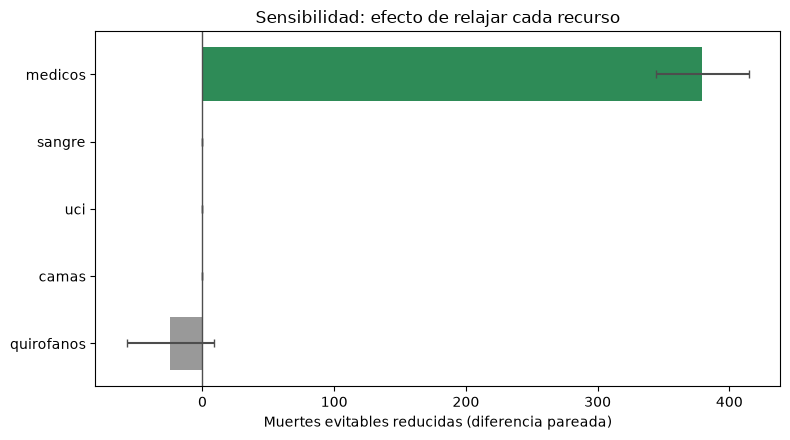

In [10]:
# Cuál de los recursos es el cuello de botella determinante. Se relaja cada uno un 20%
# sobre el escenario base y se mide cuánto baja la mortalidad evitable.
sens = montecarlo.cargar_o_correr(
    "sensibilidad20",
    lambda: montecarlo.sensibilidad_recursos(p, n=N_REP, delta=0.20, procesos=PROCESOS),
    usar_cache=USAR_CACHE, firma=(N_REP, 0.20),
)
plots.sensibilidad(sens)

columnas = ["escenario", "muertes_evitables_media", "dif_pareada_media",
            "dif_ic95_bajo", "dif_ic95_alto", "reduccion_pct", "determinante"]
print(sens[columnas].round(1).to_string(index=False))

ganador = sens[sens["determinante"]]
if len(ganador):
    fila = ganador.iloc[0]
    print(f"\nRecurso determinante: {fila['recurso']} "
          f"(−{fila['dif_pareada_media']:.0f} muertes evitables, {fila['reduccion_pct']:.1f} %).")
else:
    print("\nNingún recurso muestra un efecto distinguible de cero.")

In [11]:
# Resultados entregables de nuestro grupo para el Grupo 7.
corrida_barrido = lambda interv: montecarlo.correr_replicas(
    p, n=10, intervencion=interv, procesos=PROCESOS,
    guardar_logs=False, semillas_fijas=montecarlo.semillas(10))

saturacion = outputs.tabla_saturacion(mc)
cuellos = outputs.tabla_cuellos_botella(mc)
minimos = montecarlo.cargar_o_correr(
    "recursos_minimos",
    lambda: outputs.tabla_recursos_minimos(corrida_barrido, p, max_iter=3),
    usar_cache=USAR_CACHE, firma=10,
)

print(minimos.to_string(index=False))
print(f"\nCSV escritos en {outputs.DIR_TABLAS}")
for archivo in sorted(outputs.DIR_TABLAS.glob("*.csv")):
    print(" -", archivo.name)

        recurso     unidad  cantidad_minima  tasa_evitable_resultante  alcanza_umbral
       — base —                         0.0                    0.2305           False
camas_generales      camas              NaN                    0.2305           False
      camas_uci  camas UCI              NaN                    0.2305           False
     quirofanos quirófanos              NaN                    0.2404           False
        medicos    médicos             60.0                    0.1334            True
         sangre   unidades              NaN                    0.2305           False

CSV escritos en /home/sebas/github/ModelacionSimulacionExamenPractico/outputs/tables
 - cuellos_botella.csv
 - recursos_minimos.csv
 - saturacion_por_bloque.csv
